# import Statments

In [1]:
!pip uninstall -y tabpfn tabpfn-extensions tabpfn-common-utils
!pip install tabpfn==6.4.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 621.6/621.6 kB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.3/228.3 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 8.4 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [2]:
from tabpfn import TabPFNClassifier
import tabpfn
print(tabpfn.__version__)

6.4.1


In [3]:
!pip install "tabpfn-extensions[interpretability]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 116.5 MB/s eta 0:00:00


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tabpfn_extensions import interpretability

In [5]:
import pandas as pd                    #  data handling
import numpy as np                     #  numerical operations
import matplotlib.pyplot as plt        #  plotting
import seaborn as sns                  #  static data visualization
import plotly.express as px            #  interactive plots
import plotly.graph_objects as go
from scipy.signal import butter, filtfilt, iirnotch
import math
from scipy.stats import zscore
from scipy.stats import median_abs_deviation
import missingno as msno






# Load Data

In [6]:
path = '/content/EMG Data 3. .xlsx'
EMG_df = pd.read_excel(path)

EMG_df.head()

,patient_id,age,sex,side,dominant Hand,Nerve,MUAP Amplitude uV,MUAP Ration ms,MUAP Polyphasia Percent,Firing Rate hz,Diagnosis Severity
0,1.0,69,F,Left,Right,Median,751.0,10.0,4.7,12.8,Normal
1,2.0,26,F,Right,Right,Ulnar,2798.0,13.4,23.9,12.2,Moderate
2,3.0,47,F,Right,Right,Ulnar,946.0,9.8,5.8,8.9,Normal
3,4.0,25,M,Left,Right,Median,1217.0,8.7,14.2,20.1,Normal
4,5.0,41,F,Right,Right,Median,2763.0,16.3,22.9,17.9,Moderate


# EDA

## Data Structure Understanding

In [7]:
print("Shape of the dataset:", EMG_df.shape)

Shape of the dataset: (912, 11)


In [8]:
print("Columns:", EMG_df.columns)

Columns: Index(['patient_id', 'age', 'sex', 'side', 'dominant Hand', 'Nerve',
       'MUAP Amplitude uV', 'MUAP Ration ms', 'MUAP Polyphasia Percent',
       'Firing Rate hz', 'Diagnosis Severity'],
      dtype='object')


In [9]:
print("\nBasic statistics:\n", EMG_df.describe())


Basic statistics:
         patient_id         age  MUAP Amplitude uV  MUAP Ration ms  \
count   912.000000  912.000000         912.000000      912.000000   
mean    492.031001   49.127193         995.497697       10.884868   
std     295.707016   17.918625         614.454031        2.869307   
min       1.000000   18.000000         150.000000        3.000000   
25%     228.750000   34.000000         630.675000        9.000000   
50%     486.575758   49.000000         806.150000       10.600000   
75%     748.833333   65.000000        1145.375000       12.700000   
max    1011.090909   79.000000        4408.000000       21.300000   

       MUAP Polyphasia Percent  Firing Rate hz  
count               912.000000      912.000000  
mean                 20.536294       12.705921  
std                  12.717719        4.032833  
min                   0.000000        3.000000  
25%                  10.150000        9.900000  
50%                  19.000000       12.600000  
75%            

In [10]:
# Data Info + Memory Usage

EMG_df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               912 non-null    float64
 1   age                      912 non-null    int64  
 2   sex                      912 non-null    object 
 3   side                     912 non-null    object 
 4   dominant Hand            912 non-null    object 
 5   Nerve                    912 non-null    object 
 6   MUAP Amplitude uV        912 non-null    float64
 7   MUAP Ration ms           912 non-null    float64
 8   MUAP Polyphasia Percent  912 non-null    float64
 9   Firing Rate hz           912 non-null    float64
 10  Diagnosis Severity       912 non-null    object 
dtypes: float64(5), int64(1), object(5)
memory usage: 282.9 KB


In [11]:
#Count numeric & categorical features

# Select numeric & categorical features
numeric_features = EMG_df.select_dtypes(include=['int64', 'float64']).drop(columns=['patient_id'])
categorical_features = EMG_df.select_dtypes(include=['object', 'category'])

# column counts
print("Number of Numeric features:", len(numeric_features.columns))
print("Number of Categorical features:", len(categorical_features.columns))

# column names
print("\nNumeric feature:")
print(list(numeric_features.columns))

print("\nCategorical feature:")
print(list(categorical_features.columns))

Number of Numeric features: 5
Number of Categorical features: 5

Numeric feature:
['age', 'MUAP Amplitude uV', 'MUAP Ration ms', 'MUAP Polyphasia Percent', 'Firing Rate hz']

Categorical feature:
['sex', 'side', 'dominant Hand', 'Nerve', 'Diagnosis Severity']


## Descriptive Summary Statistics

In [12]:
# Summary stats for all numeric features

numeric_cols = EMG_df.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = numeric_cols.drop('patient_id')

EMG_df[numeric_cols].describe().T  # Transpose for readability

,count,mean,std,min,25%,50%,75%,max
age,912.0,49.127193,17.918625,18.0,34.000,49.00,65.000,79.0
MUAP Amplitude uV,912.0,995.497697,614.454031,150.0,630.675,806.15,1145.375,4408.0
MUAP Ration ms,912.0,10.884868,2.869307,3.0,9.000,10.60,12.700,21.3
MUAP Polyphasia Percent,912.0,20.536294,12.717719,0.0,10.150,19.00,27.625,65.0
Firing Rate hz,912.0,12.705921,4.032833,3.0,9.900,12.60,15.300,26.6


In [13]:
print( type(numeric_features))
print( type(numeric_cols) )

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.indexes.base.Index'>


## Target Label Distribution

In [14]:
print("Severity distribution:")
print(EMG_df['Diagnosis Severity'].value_counts())

Severity distribution:
Diagnosis Severity
Normal      353
Mild        262
Moderate    195
Severe      102
Name: count, dtype: int64


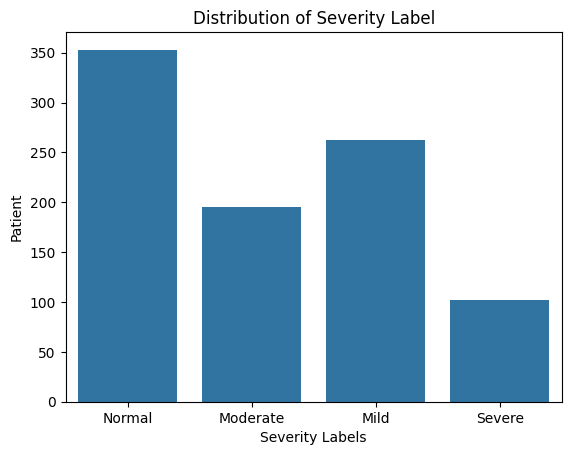

In [15]:
sns.countplot(data=EMG_df, x='Diagnosis Severity')

plt.title('Distribution of Severity Label')
plt.xlabel("Severity Labels")
plt.ylabel("Patient")
plt.show()

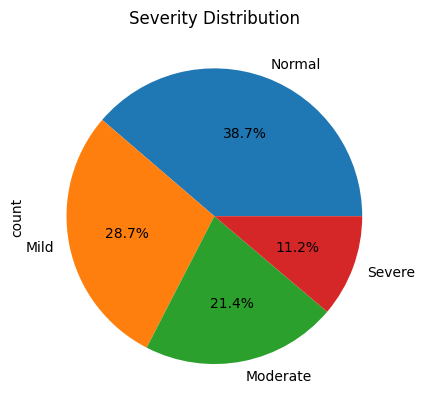

In [16]:
EMG_df['Diagnosis Severity'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Severity Distribution")
plt.show()

## Correlation Analysis

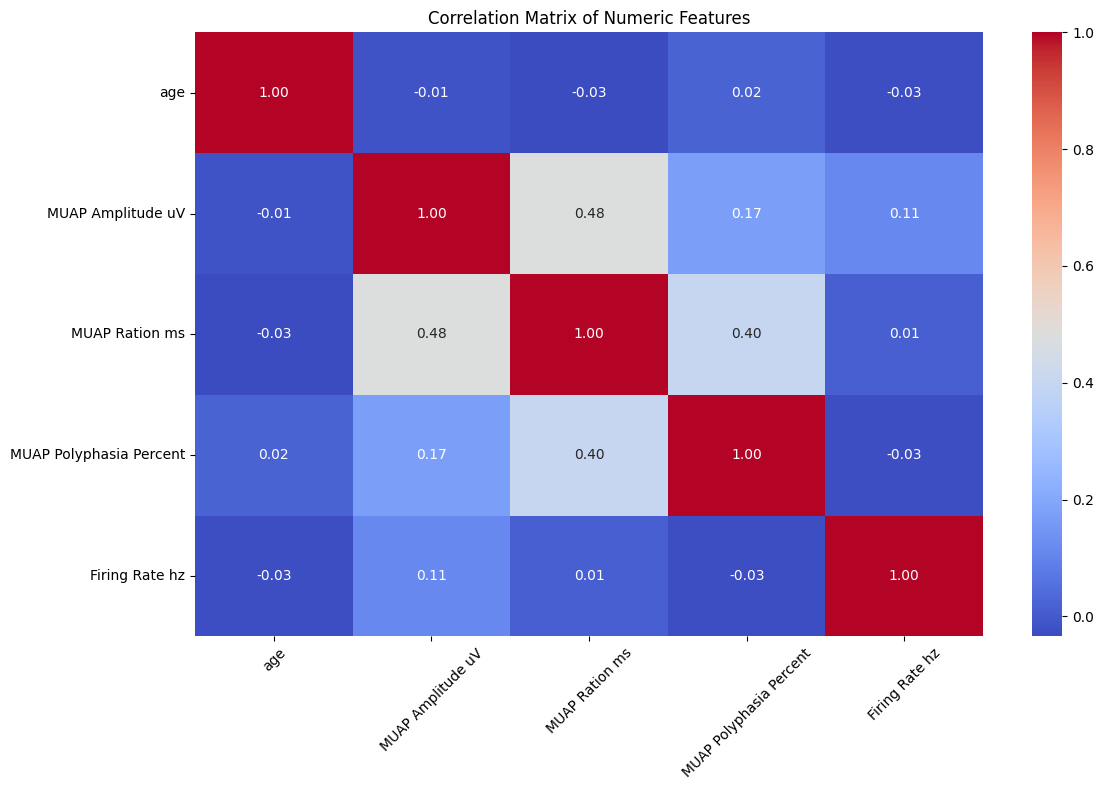

In [17]:
# Correlation matrix to detect collinear features

corr = EMG_df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

## Distribution of Each EMG Feature

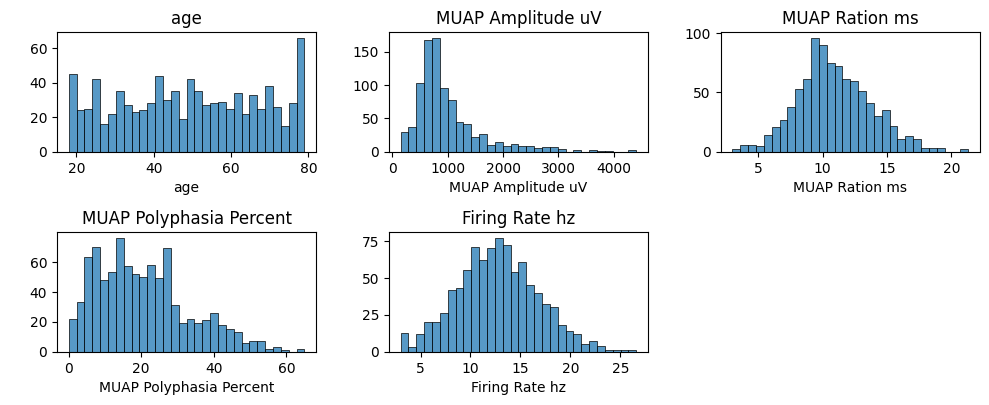

In [18]:
# number of charts per row
cols = 3

# round up the number of rows ; Ensures enough rows to display all features.
rows = math.ceil( len(numeric_features) / cols)

# Create Creates a new figure for all subplots ( witdh,height  )
plt.figure(figsize=(10, rows * 2))


for i, col in enumerate(numeric_features, 1):
    #Creates the i-th subplot in a grid of rows × cols.
    plt.subplot(rows, cols, i)

    # draws histogram + dropna() removes missing values before plottin + splits the data range into 30 buckets +  no density curve
    sns.histplot(EMG_df[col].dropna(), bins=30, kde=False)
    plt.title(f'{col}')
    plt.xlabel(col, fontsize=10)
    plt.ylabel(' ', fontsize=10)

plt.tight_layout()
plt.show()

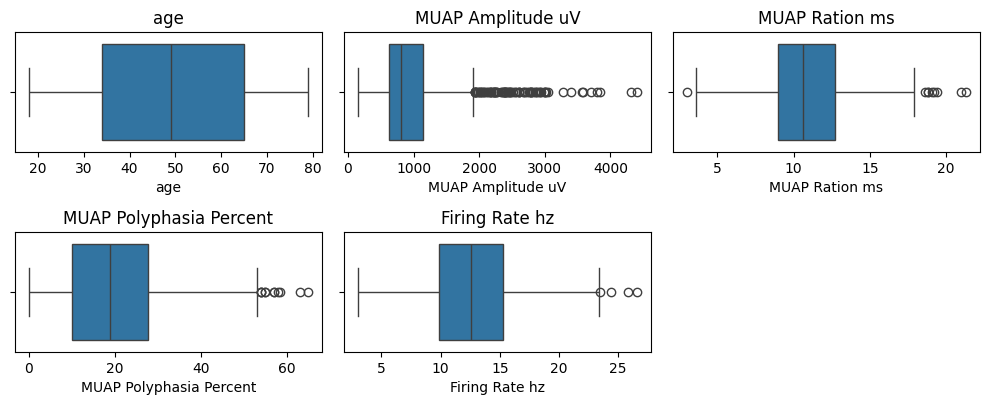

In [19]:
#  Boxplot by Nerve or Severity

plt.figure(figsize=(10, rows * 2))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=EMG_df[col].dropna())
    plt.title(f'{col}')
    plt.xlabel(col, fontsize=10)

plt.tight_layout()
plt.show()

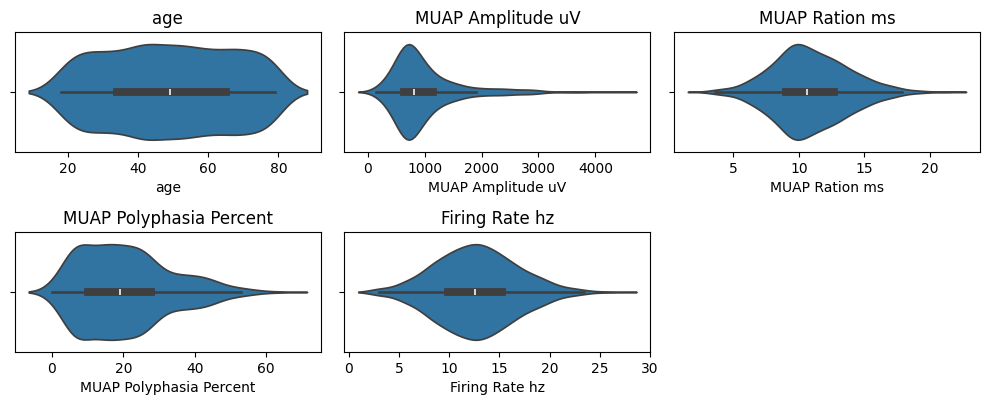

In [20]:
#Violin Plot
plt.figure(figsize=(10, rows * 2))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(rows, cols, i)
    sns.violinplot(x=EMG_df[col].dropna())
    plt.title(f'{col}')
    plt.xlabel(col, fontsize=10)

plt.tight_layout()
plt.show()

### Catagorical Features Distribution

/tmp/ipykernel_1712/1258442633.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=EMG_df, x=col, palette='Set2')
/tmp/ipykernel_1712/1258442633.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=EMG_df, x=col, palette='Set2')
/tmp/ipykernel_1712/1258442633.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=EMG_df, x=col, palette='Set2')
/tmp/ipykernel_1712/1258442633.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and s

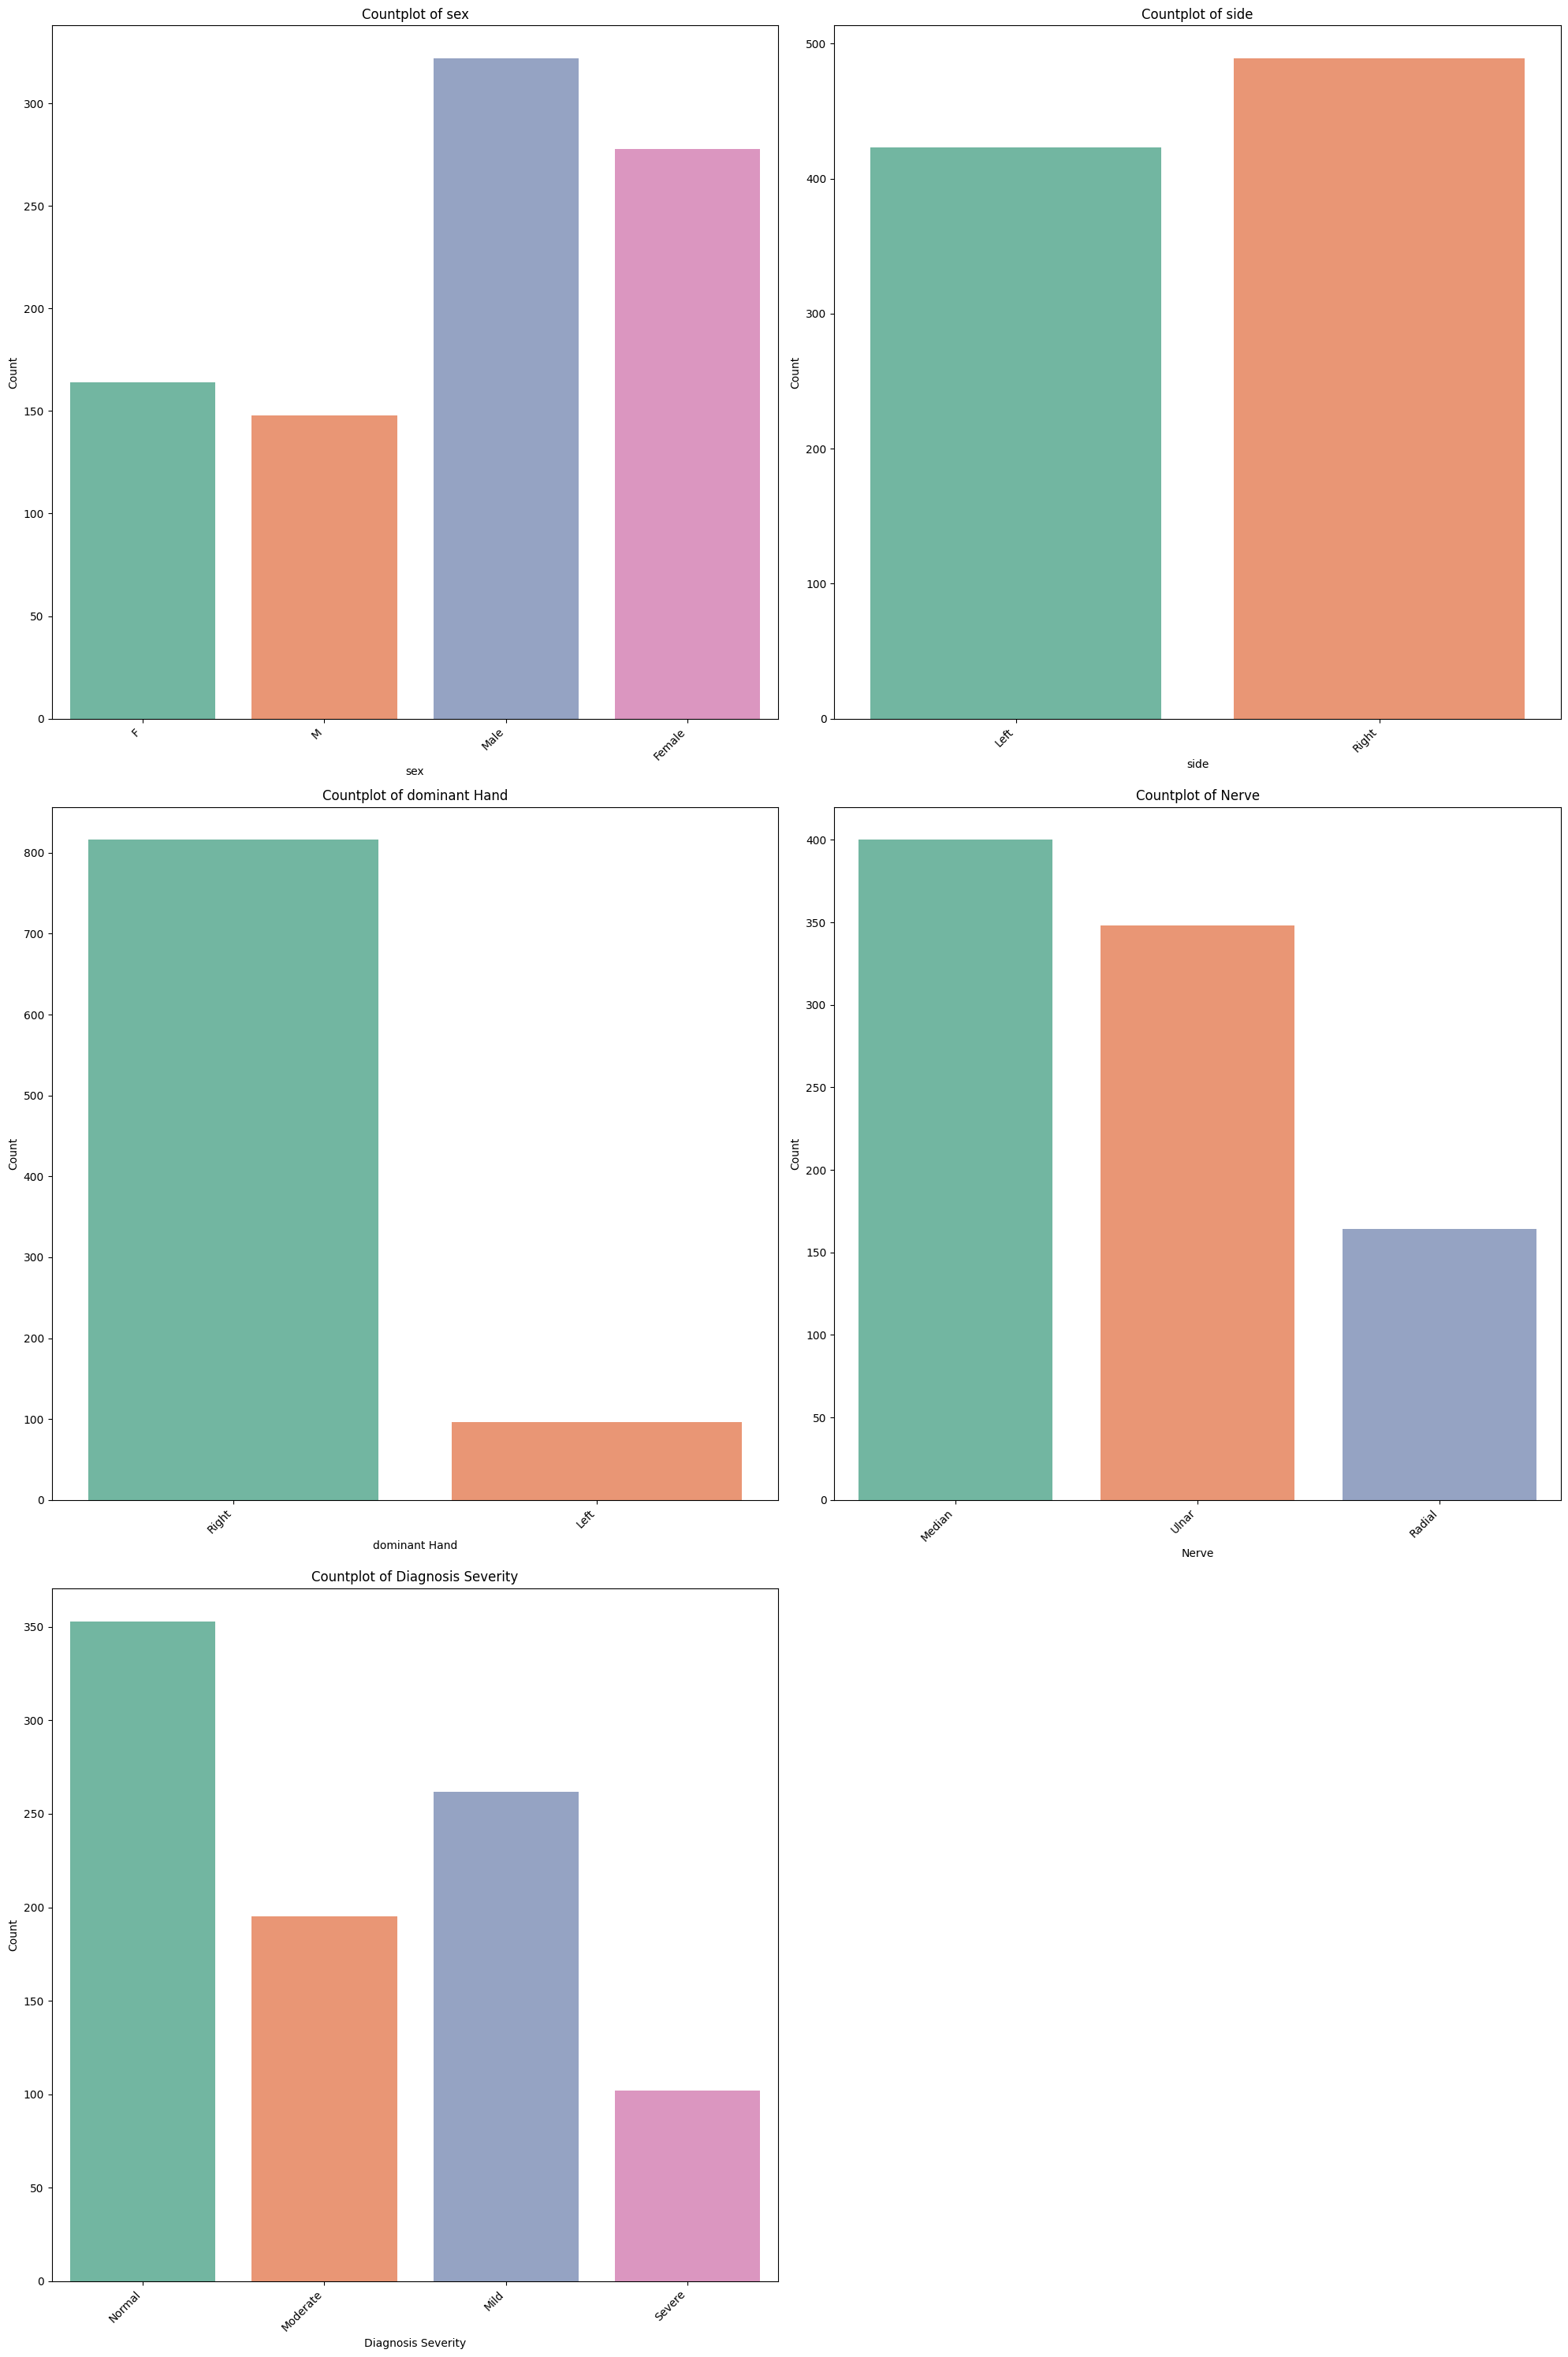

In [21]:
# Count Plot

# Select categorical columns
categorical_cols = EMG_df.select_dtypes(include=['object', 'category']).columns

# Number of categorical features
n_cat = len(categorical_cols)

# Layout
cols = 2   # number of plots per row
rows = math.ceil(n_cat / cols)

# Create figure
plt.figure(figsize=(20, rows * 10))

# Loop for subplots
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.countplot(data=EMG_df, x=col, palette='Set2')
    plt.title(f'Countplot of {col}', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

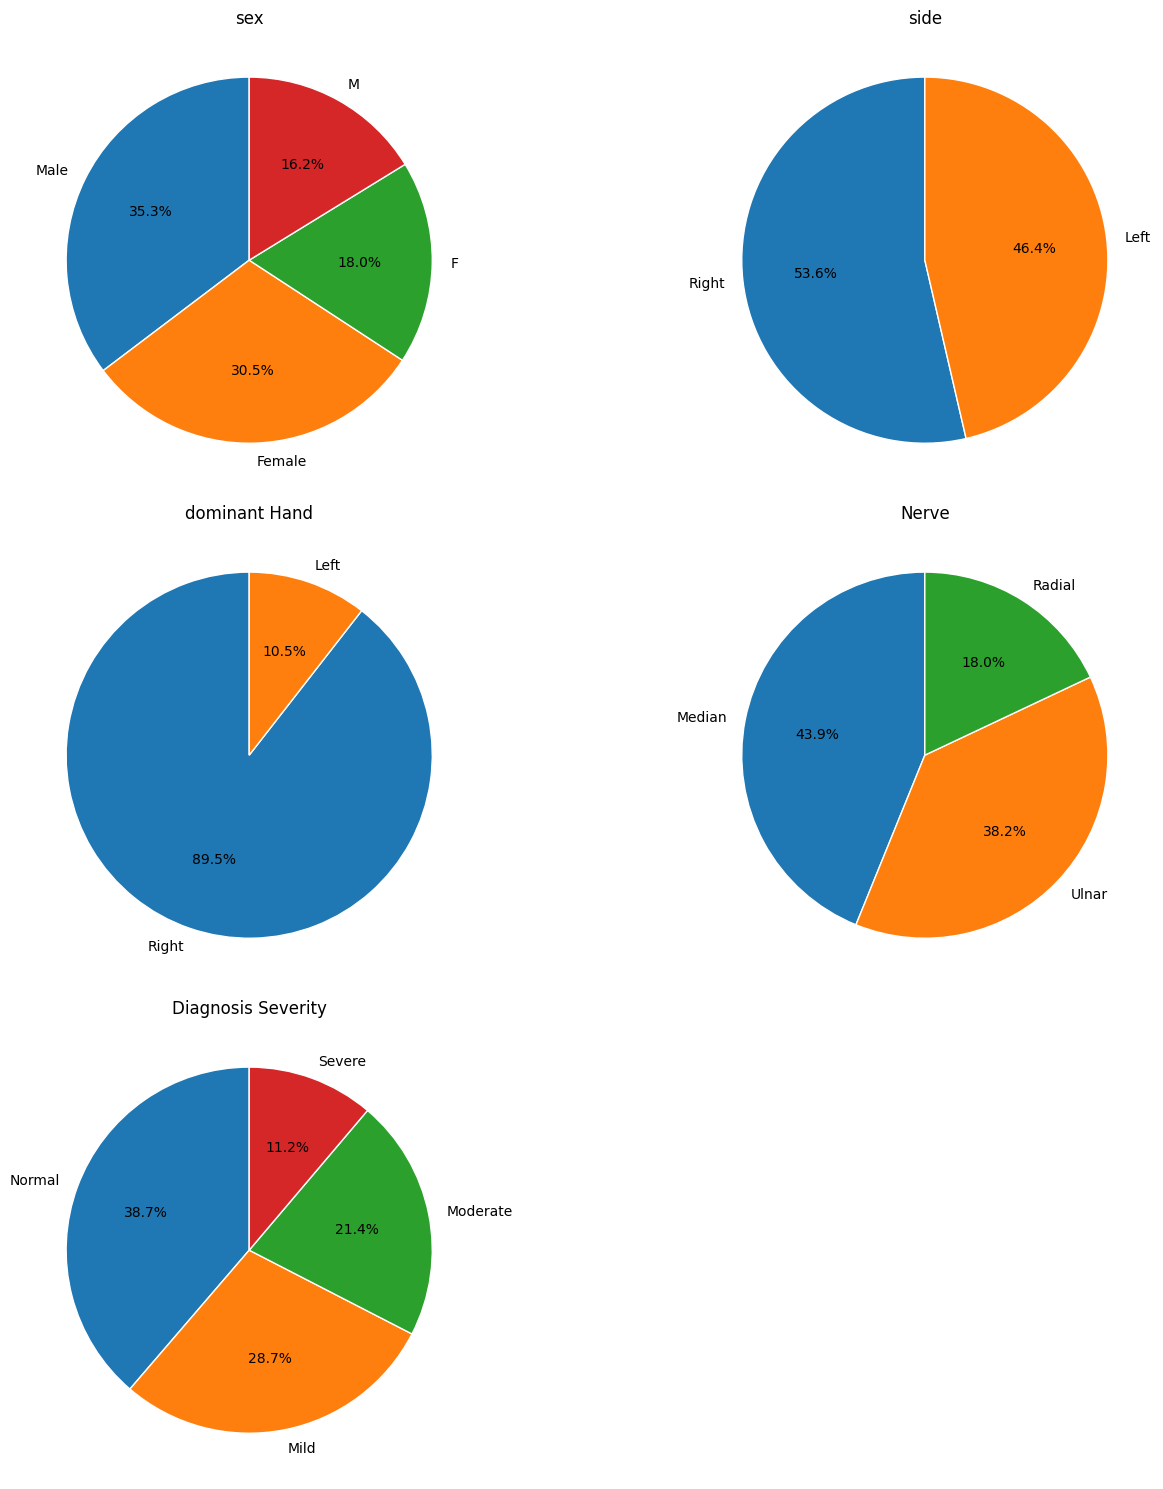

In [22]:
# Pie chart

# Select categorical columns
categorical_cols = EMG_df.select_dtypes(include=['object', 'category']).columns

# Number of categorical features
n_cat = len(categorical_cols)

# Subplot layout
cols = 2
rows = math.ceil(n_cat / cols)

# Create the figure
plt.figure(figsize=(14, rows * 5))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(rows, cols, i)

    # Get counts
    data = EMG_df[col].value_counts()

    # Pie chart
    plt.pie(
        data.values,
        labels=data.index,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 10},
        wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
    )

    plt.title(f'{col}', fontsize=12)

plt.tight_layout()
plt.show()

## Missing Values

In [23]:
print("Missing values per column:\n", EMG_df.isnull().sum()) #Nan None

Missing values per column:
 patient_id                 0
age                        0
sex                        0
side                       0
dominant Hand              0
Nerve                      0
MUAP Amplitude uV          0
MUAP Ration ms             0
MUAP Polyphasia Percent    0
Firing Rate hz             0
Diagnosis Severity         0
dtype: int64


## Duplicates Recoreds


In [24]:
dup_rows = EMG_df.duplicated().sum()
print("\nNumber of Fully Duplicated rows:", dup_rows)


Number of Fully Duplicated rows: 0


## Detecting Messy Format

In [25]:
# Detect Non-Numeric Characters Inside Numeric Columns

for col in EMG_df.select_dtypes(include='object'):
    # Check if column is supposed to be numeric
    try:
        EMG_df[col].astype(float)
        print(f"POSSIBLE WRONG FORMAT → {col}: contains numeric-like strings")
    except:
        pass


In [26]:
# Detect Leading / Trailing Spaces

for col in EMG_df.select_dtypes(include='object'):
    EMG_df[col] = EMG_df[col].astype(str)
    if EMG_df[col].str.contains(r'^\s+|\s+$').any():
        print(f"WARNING: Spaces in {col}")

In [27]:
# Detect Mixed Formats

for col in EMG_df.select_dtypes(include='object'):
    print(f"\nUnique values in {col}:")
    print(EMG_df[col].unique())


Unique values in sex:
['F' 'M' 'Male' 'Female']

Unique values in side:
['Left' 'Right']

Unique values in dominant Hand:
['Right' 'Left']

Unique values in Nerve:
['Median' 'Ulnar' 'Radial']

Unique values in Diagnosis Severity:
['Normal' 'Moderate' 'Mild' 'Severe']


In [28]:
# Detect Unexpected / Invalid Categories

for col in EMG_df.select_dtypes(include='object'):
    print(f"\n{col} → unique values:")
    print(EMG_df[col].value_counts(dropna=False))


sex → unique values:
sex
Male      322
Female    278
F         164
M         148
Name: count, dtype: int64

side → unique values:
side
Right    489
Left     423
Name: count, dtype: int64

dominant Hand → unique values:
dominant Hand
Right    816
Left      96
Name: count, dtype: int64

Nerve → unique values:
Nerve
Median    400
Ulnar     348
Radial    164
Name: count, dtype: int64

Diagnosis Severity → unique values:
Diagnosis Severity
Normal      353
Mild        262
Moderate    195
Severe      102
Name: count, dtype: int64


In [29]:
# Detect Columns with Mixed Types

for col in EMG_df.columns:
    types = EMG_df[col].apply(type).value_counts()
    if len(types) > 1:
        print(f"Mixed types in {col}: {types}")

In [30]:
# Detect Symbols or Patterns in Categorical Columns

import re

for col in EMG_df.select_dtypes(include='object'):
    if EMG_df[col].str.contains(r'\(|\)|\+|\-').any():
        print(f"Possible encoded scale in {col}")

# Preprocessing

##Data Cleaning

In [31]:
EMG_df['sex'] = EMG_df['sex'].replace({
    'M': 'Male',
    'F': 'Female'
})

In [32]:
EMG_df['sex'].value_counts()

,count
sex,
Male,470
Female,442


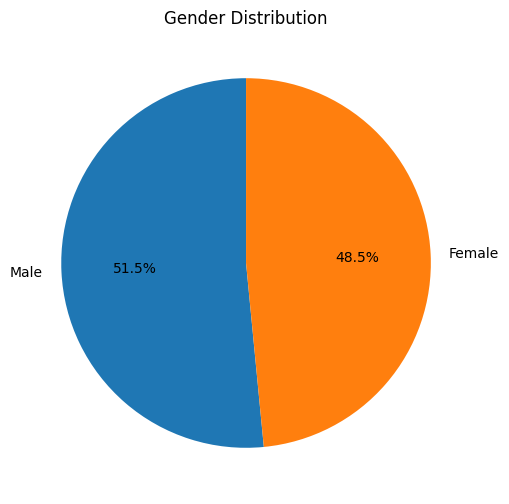

In [33]:
sex_counts = EMG_df['sex'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(sex_counts,
        labels=sex_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Gender Distribution")
plt.show()

In [34]:
EMG_df['dominant Hand'] = EMG_df['dominant Hand'].replace({
    'left': 'Left',
    'right': 'Right'
})

In [35]:
EMG_df = EMG_df.drop(columns=['patient_id'])

##Encoding

In [36]:
EMG_encoded = EMG_df.copy()

###1) Binary Encoding

In [37]:
# Encode binary categorical variables using Mapping


EMG_encoded['sex'] = EMG_encoded['sex'].map({
    'Male': 1,
    'Female': 0
})

EMG_encoded['side'] = EMG_encoded['side'].map({
    'Right': 1,
    'Left': 0
})

EMG_encoded['dominant Hand'] = EMG_encoded['dominant Hand'].map({
    'Right': 1,
    'Left': 0
})

###**2) cat.codes**

In [38]:
EMG_encoded['Nerve'] = EMG_encoded['Nerve'].astype('category').cat.codes

###**3) Ordinal Encoding**

In [39]:
# Encode the target variable (Diagnosis Severity)

EMG_encoded['Diagnosis Severity'] = EMG_encoded['Diagnosis Severity'].map({
    'Normal': 0,
    'Mild': 1,
    'Moderate': 2,
    'Severe': 3
})

##Arrange Cols

In [40]:
# Define the target column (the variable we want the model to predict)
target = 'Diagnosis Severity'


# Create a list of columns where the target column is placed at the end
# First take all columns except the target, then add the target column last
cols = [col for col in EMG_encoded.columns if col != target] + [target]


# Reorder the dataframe columns based on the new column list to ensures the target variable appears as the last column
EMG_encoded = EMG_encoded[cols]


# Display the first 5 rows of the dataframe to verify the new column order
EMG_encoded.head()

,age,sex,side,dominant Hand,Nerve,MUAP Amplitude uV,MUAP Ration ms,MUAP Polyphasia Percent,Firing Rate hz,Diagnosis Severity
0,69,0,0,1,0,751.0,10.0,4.7,12.8,0
1,26,0,1,1,2,2798.0,13.4,23.9,12.2,2
2,47,0,1,1,2,946.0,9.8,5.8,8.9,0
3,25,1,0,1,0,1217.0,8.7,14.2,20.1,0
4,41,0,1,1,0,2763.0,16.3,22.9,17.9,2


##**Train/Test Split**

In [41]:
from sklearn.model_selection import train_test_split

# Separate
X = EMG_encoded.drop(columns=['Diagnosis Severity'])

# target variable
y = EMG_encoded['Diagnosis Severity']


# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,                 # Feature matrix (input variables)
    y,                 # Target variable
    test_size=0.2,     # 20% of the data will be used for testing
    random_state=42,   # Ensures reproducibility (same split every run)
    stratify=y         # Keeps the same class distribution in train and test sets
)

##**Feature Selection**

###1) Statistical Feature Selection

**1) Kruskal-Wallis Test For The Numeric Feature**

In [42]:
from scipy.stats import kruskal
import pandas as pd

# List of numerical features to test their relationship with the target variable
numeric_features = [
    'age',
    'MUAP Amplitude uV',
    'MUAP Ration ms',
    'MUAP Polyphasia Percent',
    'Firing Rate hz'
]

# List to store test results
results = []

# Loop through each numeric feature
for feature in numeric_features:

    # Create a list that will hold the values of the feature for each class of the target
    groups = []

    # For each class in the target variable (Diagnosis Severity)
    for cls in y_train.unique():
        # Select values of the feature corresponding to that class
        groups.append(X_train[y_train == cls][feature])

    # Apply the Kruskal-Wallis test to compare distributions across groups
    stat, p = kruskal(*groups)

    # Store the feature name and its p-value
    results.append({
        'Feature': feature,
        'p-value': p
    })

# Convert results into a DataFrame for easier analysis
results_df = pd.DataFrame(results)

# Mark features as significant if p-value ≤ 0.05
results_df["Significant (p≤0.05)"] = results_df["p-value"].apply(
    lambda x: "Yes" if x <= 0.05 else "No"
)

# Sort features by p-value (most significant first)
results_df = results_df.sort_values("p-value")

# Display the results
results_df

,Feature,p-value,Significant (p≤0.05)
3,MUAP Polyphasia Percent,2.223773e-88,Yes
2,MUAP Ration ms,4.456013e-50,Yes
1,MUAP Amplitude uV,1.568909e-26,Yes
4,Firing Rate hz,2.111645e-01,No
0,age,2.169704e-01,No


**2) Chi-Square Test For The Categorical Features**

In [43]:
from scipy.stats import chi2_contingency
import pandas as pd

# List of categorical features to test their relationship with the target
categorical_features = [
    'sex',
    'side',
    'dominant Hand',
    'Nerve'
]

# List to store chi-square test results
chi_results = []

# Loop through each categorical feature
for feature in categorical_features:

    # Create a contingency table between the feature and the target variable
    table = pd.crosstab(X_train[feature], y_train)

    # Perform the Chi-Square test of independence
    chi2, p, dof, expected = chi2_contingency(table)

    # Store the feature name and its p-value
    chi_results.append({
        "Feature": feature,
        "p-value": p
    })

# Convert results into a DataFrame
chi_df = pd.DataFrame(chi_results)

# Sort features by p-value (most significant first)
chi_df = chi_df.sort_values("p-value")

# Mark features as significant if p-value ≤ 0.05
chi_df["Significant (p≤0.05)"] = chi_df["p-value"].apply(
    lambda x: "Yes" if x <= 0.05 else "No"
)

# Display the results
chi_df

,Feature,p-value,Significant (p≤0.05)
1,side,0.020407,Yes
3,Nerve,0.228387,No
2,dominant Hand,0.412273,No
0,sex,0.511668,No


###2) Fisher Score

In [44]:
# ANOVA F-test function
from sklearn.feature_selection import f_classif
import pandas as pd


# Apply the ANOVA F-test between each feature in X_train and the target variable y_train
# This test evaluates whether the mean values of a feature differ significantly across target classes
f_scores, p_values = f_classif(
    X_train,
    y_train
    )


# create Df to organize the results
fisher_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Fisher Score': f_scores,
    'p-value': p_values
})


# Sort descending order : Higher Fisher Score indicates stronger relationship with the target variable
fisher_df = fisher_df.sort_values(by='Fisher Score', ascending=False)



fisher_df

,Feature,Fisher Score,p-value
7,MUAP Polyphasia Percent,391.294215,4.420249e-151
6,MUAP Ration ms,123.431891,1.382409e-64
5,MUAP Amplitude uV,63.614080,1.609797e-36
2,side,3.290757,2.022990e-02
0,age,1.461124,2.238847e-01
8,Firing Rate hz,1.325265,2.649770e-01
3,dominant Hand,0.954832,4.135851e-01
1,sex,0.766359,5.130919e-01
4,Nerve,0.495308,6.856380e-01


# ________________________________________________________________________________________________________

#Model Implementation - Baseline

##TabPFN

In [45]:
import warnings
warnings.filterwarnings("ignore")

##### Cross Vaildation Function

In [46]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, average_precision_score,
    classification_report, confusion_matrix
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabpfn import TabPFNClassifier


def run_tabpfn_stratified_cv(X, y, experiment_name):
    # Copy features to avoid changing original data
    X = X.copy()
    X.columns = X.columns.str.replace(' ', '_')

    # Define target mapping
    target_mapping = {
        'Normal': 0,
        'Mild': 1,
        'Moderate': 2,
        'Severe': 3
    }

    # Convert y if it is still text labels
    if y.dtype == 'object':
        y = y.map(target_mapping)

    # Keep class order fixed
    sorted_classes = sorted(target_mapping.items(), key=lambda x: x[1])
    class_names = [name for name, _ in sorted_classes]
    class_labels = [label for _, label in sorted_classes]

    # Get Severe class info for AP
    severe_label = target_mapping['Severe']
    severe_index = class_labels.index(severe_label)

    # Stratified 5-fold CV
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Store outputs
    metrics_list = []
    fold_reports = []
    confusion_matrices = []

    # Store all predictions across folds
    all_y_true = []
    all_y_pred = []
    all_y_proba = []

    print("\n" + "=" * 100)
    print(f"Experiment: {experiment_name}")
    print("=" * 100)

    # Loop through folds
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):

        # Split current fold
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        # Train model
        model = TabPFNClassifier()
        model.fit(X_train_fold, y_train_fold)

        # Predict labels and probabilities
        y_pred = model.predict(X_val_fold)
        y_proba = model.predict_proba(X_val_fold)

        # Save all predictions across folds
        all_y_true.extend(y_val_fold.tolist())
        all_y_pred.extend(y_pred.tolist())
        all_y_proba.append(y_proba)

        # Calculate fold metrics
        acc = accuracy_score(y_val_fold, y_pred)
        precision_macro = precision_score(y_val_fold, y_pred, average='macro', zero_division=0)
        recall_macro = recall_score(y_val_fold, y_pred, average='macro', zero_division=0)
        f1_macro = f1_score(y_val_fold, y_pred, average='macro', zero_division=0)
        mcc = matthews_corrcoef(y_val_fold, y_pred)

        # Calculate AP for Severe class
        y_val_severe = (y_val_fold == severe_label).astype(int)
        y_proba_severe = y_proba[:, severe_index]
        ap_severe = average_precision_score(y_val_severe, y_proba_severe)

        # Save fold metrics
        metrics_list.append({
            'Fold': fold,
            'Accuracy': round(acc, 4),
            'Precision_macro': round(precision_macro, 4),
            'Recall_macro': round(recall_macro, 4),
            'F1_macro': round(f1_macro, 4),
            'MCC': round(mcc, 4),
            'AP_Severe': round(ap_severe, 4)
        })

        # Build classification report for current fold
        report_dict = classification_report(
            y_val_fold,
            y_pred,
            labels=class_labels,
            target_names=class_names,
            output_dict=True,
            zero_division=0
        )

        report_df = pd.DataFrame(report_dict).transpose()
        report_df.insert(0, 'Fold', fold)
        fold_reports.append(report_df)

        # Build confusion matrix for current fold
        cm = confusion_matrix(y_val_fold, y_pred, labels=class_labels)
        confusion_matrices.append(cm)

    # Convert fold metrics to DataFrame
    summary_df = pd.DataFrame(metrics_list)

    print("\nFold-wise Metrics")
    print("-" * 100)
    display(summary_df)

    print("\nClassification Report for Each Fold")
    print("-" * 100)
    for i, report_df in enumerate(fold_reports, start=1):
        print(f"\nFold {i}")
        display(report_df.loc[class_names + ['accuracy', 'macro avg', 'weighted avg']])

    print("\n" + "=" * 100)
    print("Confusion Matrices for Each Fold")
    print("=" * 100)

    # Plot confusion matrix for each fold
    for i, cm in enumerate(confusion_matrices, start=1):
        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names
        )
        plt.title(f"{experiment_name} - Fold {i}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()

    # Convert all predictions to arrays
    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)
    all_y_proba = np.vstack(all_y_proba)

    # Aggregated metrics across all folds
    agg_accuracy = accuracy_score(all_y_true, all_y_pred)
    agg_precision = precision_score(all_y_true, all_y_pred, average='macro', zero_division=0)
    agg_recall = recall_score(all_y_true, all_y_pred, average='macro', zero_division=0)
    agg_f1 = f1_score(all_y_true, all_y_pred, average='macro', zero_division=0)
    agg_mcc = matthews_corrcoef(all_y_true, all_y_pred)

    # Aggregated AP for Severe class
    y_true_severe = (all_y_true == severe_label).astype(int)
    y_proba_severe_all = all_y_proba[:, severe_index]
    agg_ap_severe = average_precision_score(y_true_severe, y_proba_severe_all)

    aggregated_metrics_df = pd.DataFrame([{
        'Accuracy': round(agg_accuracy, 4),
        'Precision_macro': round(agg_precision, 4),
        'Recall_macro': round(agg_recall, 4),
        'F1_macro': round(agg_f1, 4),
        'MCC': round(agg_mcc, 4),
        'AP_Severe': round(agg_ap_severe, 4)
    }])

    print("\nAggregated Metrics Across All Folds")
    print("-" * 100)
    display(aggregated_metrics_df)

    # Aggregated classification report across all folds
    aggregated_report_dict = classification_report(
        all_y_true,
        all_y_pred,
        labels=class_labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    aggregated_report_df = pd.DataFrame(aggregated_report_dict).transpose().round(4)

    print("\nAggregated Classification Report Across All Folds")
    print("-" * 100)
    display(aggregated_report_df.loc[class_names + ['accuracy', 'macro avg', 'weighted avg']])

    # Aggregated confusion matrix
    total_cm = np.sum(confusion_matrices, axis=0)

    print("\n" + "=" * 100)
    print("Aggregated Confusion Matrix")
    print("=" * 100)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        total_cm,
        annot=True,
        fmt='d',
        cmap='Greens',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"{experiment_name} - Aggregated Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # Combine all fold reports
    all_reports_df = pd.concat(fold_reports, axis=0)

    return summary_df, all_reports_df, aggregated_metrics_df, aggregated_report_df, total_cm

### ALL FEATURES


Experiment: TabPFN Baseline - All Features


tabpfn-v2.5-classifier-v2.5_default.ckpt:   0%|          | 0.00/42.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]


Fold-wise Metrics
----------------------------------------------------------------------------------------------------


,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1,0.7329,0.7606,0.7388,0.7428,0.6254,0.9102
1,2,0.6507,0.6390,0.6494,0.6384,0.5077,0.9327
2,3,0.6918,0.6858,0.6631,0.6623,0.5684,0.8944
3,4,0.6644,0.6689,0.6532,0.6566,0.5267,0.7739
4,5,0.6759,0.6819,0.6964,0.6866,0.5433,0.8720


...


Fold 4


,Fold,precision,recall,f1-score,support
Normal,4,0.681818,0.803571,0.737705,56.000000
Mild,4,0.593750,0.452381,0.513514,42.000000
Moderate,4,0.666667,0.709677,0.687500,31.000000
Severe,4,0.733333,0.647059,0.687500,17.000000
accuracy,4,0.664384,0.664384,0.664384,0.664384
macro avg,4,0.668892,0.653172,0.656555,146.000000
weighted avg,4,0.659265,0.664384,0.656706,146.000000



Fold 5


,Fold,precision,recall,f1-score,support
Normal,5,0.711864,0.750000,0.730435,56.000000
Mild,5,0.575000,0.547619,0.560976,42.000000
Moderate,5,0.703704,0.612903,0.655172,31.000000
Severe,5,0.736842,0.875000,0.800000,16.000000
accuracy,5,0.675862,0.675862,0.675862,0.675862
macro avg,5,0.681853,0.696381,0.686646,145.000000
weighted avg,5,0.673232,0.675862,0.672936,145.000000



Confusion Matrices for Each Fold


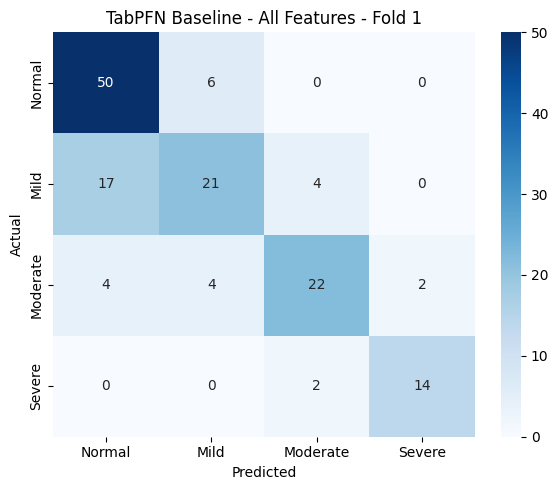

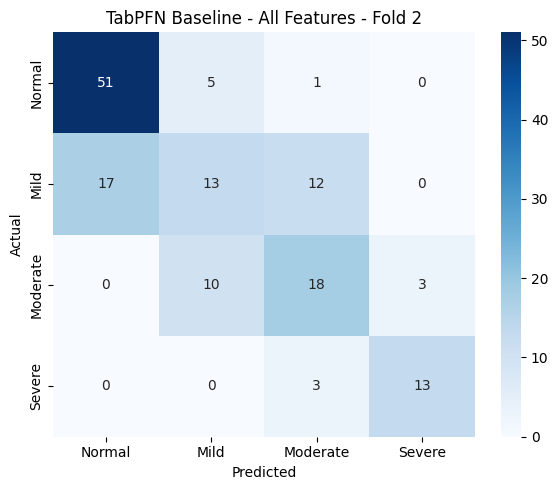

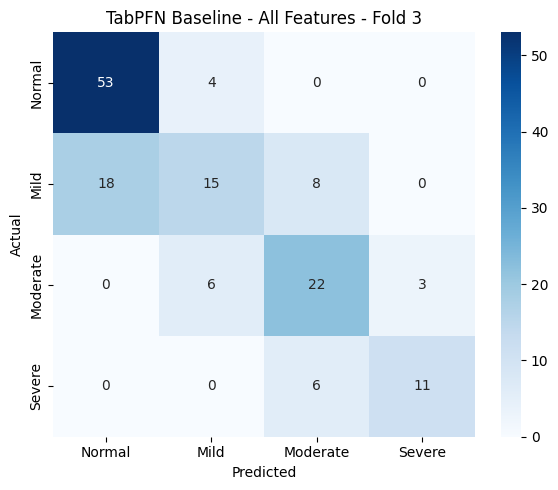

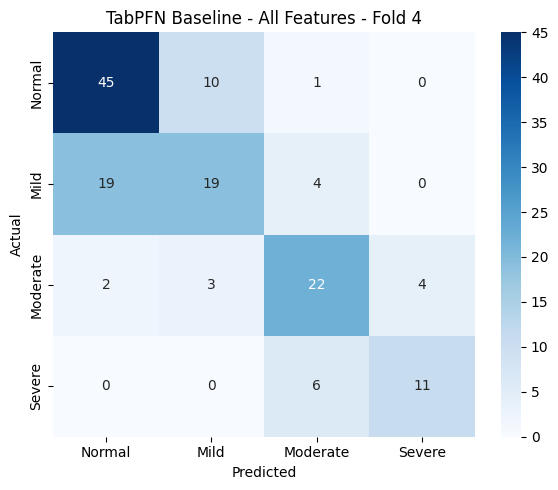

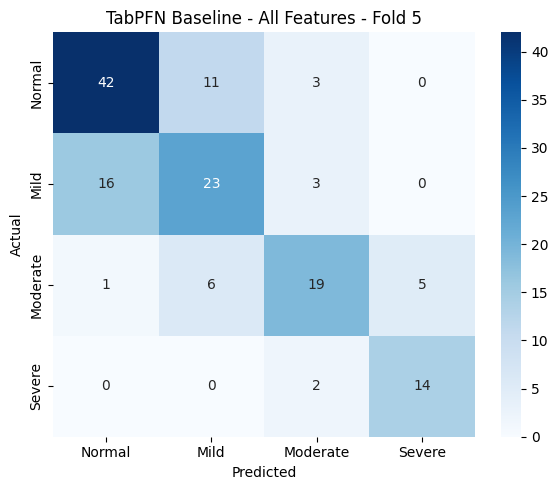


Aggregated Metrics Across All Folds
----------------------------------------------------------------------------------------------------


,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,0.6831,0.6855,0.6796,0.6784,0.553,0.8722



Aggregated Classification Report Across All Folds
----------------------------------------------------------------------------------------------------


,precision,recall,f1-score,support
Normal,0.7194,0.8546,0.7812,282.0000
Mild,0.5833,0.4354,0.4986,209.0000
Moderate,0.6519,0.6603,0.6561,156.0000
Severe,0.7875,0.7683,0.7778,82.0000
accuracy,0.6831,0.6831,0.6831,0.6831
macro avg,0.6855,0.6796,0.6784,729.0000
weighted avg,0.6736,0.6831,0.6730,729.0000



Aggregated Confusion Matrix


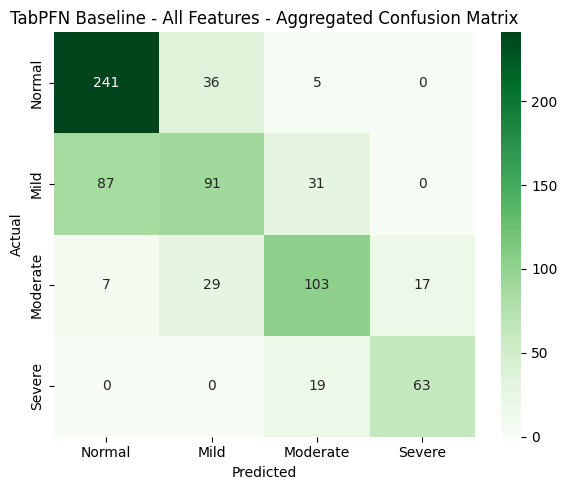

In [47]:
tabpfn_all_results, tabpfn_all_reports, tabpfn_all_agg_metrics, tabpfn_all_agg_report, tabpfn_all_cm = run_tabpfn_stratified_cv(
    X=X_train,
    y=y_train,
    experiment_name='TabPFN Baseline - All Features'
)

### SELECTED FEATURES


Experiment: TabPFN - Selected Features

Fold-wise Metrics
----------------------------------------------------------------------------------------------------


,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1,0.7123,0.7253,0.7158,0.7118,0.5976,0.9301
1,2,0.6575,0.6448,0.6613,0.6468,0.5171,0.9216
2,3,0.6712,0.6634,0.6428,0.6404,0.5388,0.8621
3,4,0.6644,0.6653,0.6511,0.6550,0.5263,0.7833
4,5,0.6897,0.6902,0.7038,0.6937,0.5625,0.8941



Classification Report for Each Fold
----------------------------------------------------------------------------------------------------

Fold 1


,Fold,precision,recall,f1-score,support
Normal,1,0.708333,0.910714,0.796875,56.000000
Mild,1,0.655172,0.452381,0.535211,42.000000
Moderate,1,0.714286,0.625000,0.666667,32.000000
Severe,1,0.823529,0.875000,0.848485,16.000000
accuracy,1,0.712329,0.712329,0.712329,0.712329
macro avg,1,0.725330,0.715774,0.711809,146.000000
weighted avg,1,0.706969,0.712329,0.698719,146.000000



Fold 2


...


Fold 4


,Fold,precision,recall,f1-score,support
Normal,4,0.703125,0.803571,0.750000,56.000000
Mild,4,0.588235,0.476190,0.526316,42.000000
Moderate,4,0.636364,0.677419,0.656250,31.000000
Severe,4,0.733333,0.647059,0.687500,17.000000
accuracy,4,0.664384,0.664384,0.664384,0.664384
macro avg,4,0.665264,0.651060,0.655016,146.000000
weighted avg,4,0.659417,0.664384,0.658469,146.000000



Fold 5


,Fold,precision,recall,f1-score,support
Normal,5,0.725806,0.803571,0.762712,56.000000
Mild,5,0.594595,0.523810,0.556962,42.000000
Moderate,5,0.703704,0.612903,0.655172,31.000000
Severe,5,0.736842,0.875000,0.800000,16.000000
accuracy,5,0.689655,0.689655,0.689655,0.689655
macro avg,5,0.690237,0.703821,0.693712,145.000000
weighted avg,5,0.684293,0.689655,0.684239,145.000000



Confusion Matrices for Each Fold


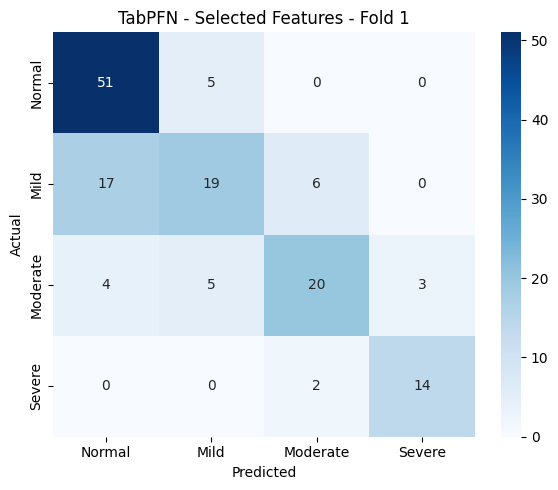

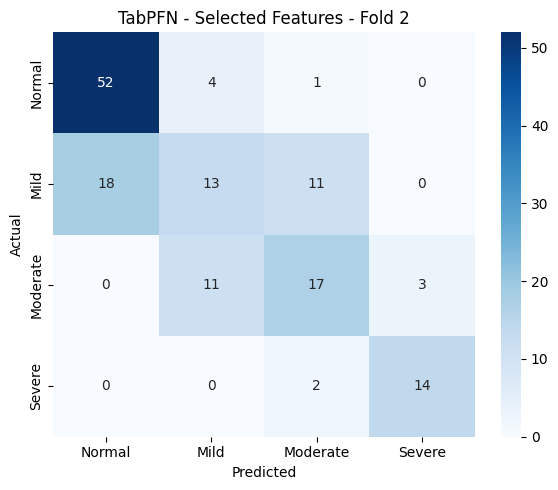

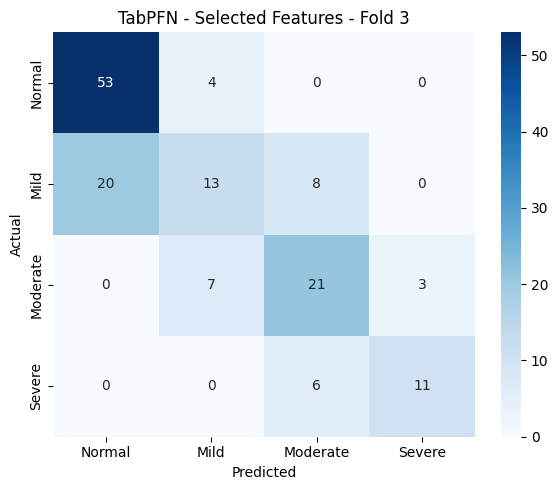

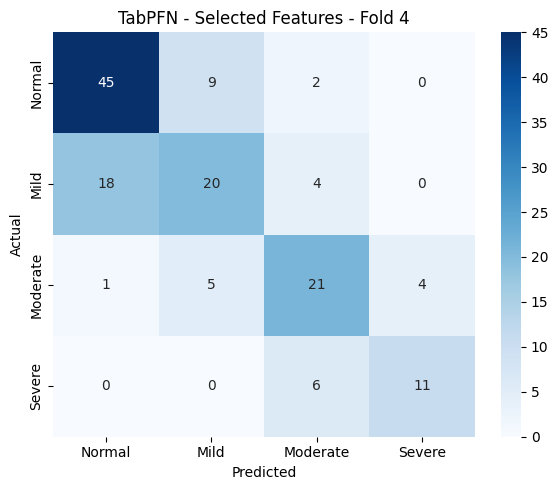

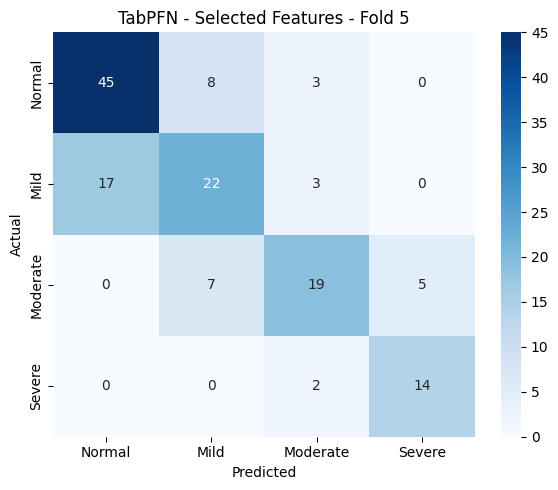


Aggregated Metrics Across All Folds
----------------------------------------------------------------------------------------------------


,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,0.679,0.6777,0.6743,0.6711,0.5474,0.867



Aggregated Classification Report Across All Folds
----------------------------------------------------------------------------------------------------


,precision,recall,f1-score,support
Normal,0.7214,0.8723,0.7897,282.000
Mild,0.5724,0.4163,0.4820,209.000
Moderate,0.6364,0.6282,0.6323,156.000
Severe,0.7805,0.7805,0.7805,82.000
accuracy,0.6790,0.6790,0.6790,0.679
macro avg,0.6777,0.6743,0.6711,729.000
weighted avg,0.6671,0.6790,0.6668,729.000



Aggregated Confusion Matrix


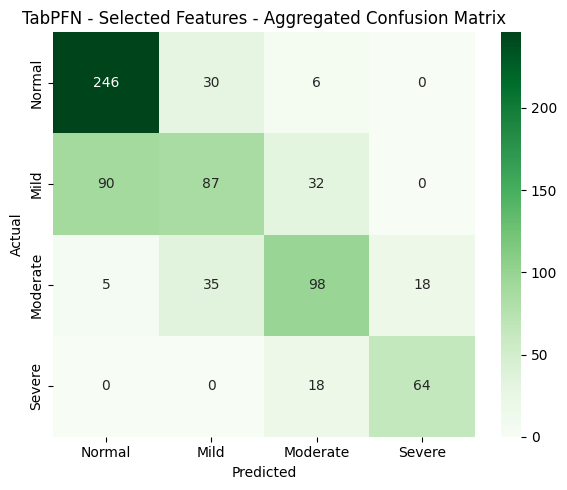

In [48]:
selected_features = [
    'MUAP Amplitude uV',
    'MUAP Ration ms',
    'MUAP Polyphasia Percent'

]

X_train_selected = X_train[selected_features].copy()

tabpfn_selected_results, tabpfn_selected_reports, tabpfn_selected_agg_metrics, tabpfn_selected_agg_report, tabpfn_selected_cm = run_tabpfn_stratified_cv(
    X=X_train_selected,
    y=y_train,
    experiment_name='TabPFN - Selected Features'
)

# Comparison

In [49]:
tabpfn_comparison = pd.DataFrame({
    'All Features': tabpfn_all_results.drop(columns='Fold').mean(),
    'Selected Features': tabpfn_selected_results.drop(columns='Fold').mean()
})

print("TabPFN Baseline Comparison")
display(tabpfn_comparison)

TabPFN Baseline Comparison


,All Features,Selected Features
Accuracy,0.68314,0.67902
Precision_macro,0.68724,0.67780
Recall_macro,0.68018,0.67496
F1_macro,0.67734,0.66954
MCC,0.55430,0.54846
AP_Severe,0.87664,0.87824


In [50]:
print("All Features - Aggregated Classification Report")
display(tabpfn_all_agg_report.loc[['Normal', 'Mild', 'Moderate', 'Severe', 'accuracy', 'macro avg', 'weighted avg']])

print("-" * 100)

print("\nSelected Features - Aggregated Classification Report")
display(tabpfn_selected_agg_report.loc[['Normal', 'Mild', 'Moderate', 'Severe', 'accuracy', 'macro avg', 'weighted avg']])

All Features - Aggregated Classification Report


,precision,recall,f1-score,support
Normal,0.7194,0.8546,0.7812,282.0000
Mild,0.5833,0.4354,0.4986,209.0000
Moderate,0.6519,0.6603,0.6561,156.0000
Severe,0.7875,0.7683,0.7778,82.0000
accuracy,0.6831,0.6831,0.6831,0.6831
macro avg,0.6855,0.6796,0.6784,729.0000
weighted avg,0.6736,0.6831,0.6730,729.0000


----------------------------------------------------------------------------------------------------

Selected Features - Aggregated Classification Report


,precision,recall,f1-score,support
Normal,0.7214,0.8723,0.7897,282.000
Mild,0.5724,0.4163,0.4820,209.000
Moderate,0.6364,0.6282,0.6323,156.000
Severe,0.7805,0.7805,0.7805,82.000
accuracy,0.6790,0.6790,0.6790,0.679
macro avg,0.6777,0.6743,0.6711,729.000
weighted avg,0.6671,0.6790,0.6668,729.000


# Final TabPFN Model (EMG)

## Reatrin on full train set

In [51]:
# Select final dataset (Selected Features only)
X_train_final = X_train[selected_features].copy()
X_test_final = X_test[selected_features].copy()

X_train_final.columns = X_train_final.columns.str.replace(' ', '_')
X_test_final.columns = X_test_final.columns.str.replace(' ', '_')

# Debug shapes and features
print("Final training shape :", X_train_final.shape)
print("Final testing shape  :", X_test_final.shape)
print("Selected features    :", list(X_train_final.columns))

Final training shape : (729, 3)
Final testing shape  : (183, 3)
Selected features    : ['MUAP_Amplitude_uV', 'MUAP_Ration_ms', 'MUAP_Polyphasia_Percent']


In [52]:
# Define target mapping
target_mapping = {
    'Normal': 0,
    'Mild': 1,
    'Moderate': 2,
    'Severe': 3
}

# Convert y if still text
if y_train.dtype == 'object':
    y_train_final = y_train.map(target_mapping)
else:
    y_train_final = y_train.copy()

if y_test.dtype == 'object':
    y_test_final = y_test.map(target_mapping)
else:
    y_test_final = y_test.copy()

print("Unique train labels:", sorted(y_train_final.unique()))
print("Unique test labels :", sorted(y_test_final.unique()))

Unique train labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Unique test labels : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [53]:
from tabpfn import TabPFNClassifier

# Build final TabPFN model
final_tabpfn_model = TabPFNClassifier()

# Train final model on the full training set
final_tabpfn_model.fit(X_train_final, y_train_final)

print("Final TabPFN model has been trained on the full training set.")

Final TabPFN model has been trained on the full training set.


## Test set evaluation

In [54]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, average_precision_score
)
import pandas as pd

# Class names and labels
class_names = ['Normal', 'Mild', 'Moderate', 'Severe']
class_labels = [0, 1, 2, 3]

# Severe class info
severe_label = 3
severe_index = class_labels.index(severe_label)

# Predict on test set
y_test_pred = final_tabpfn_model.predict(X_test_final)
y_test_proba = final_tabpfn_model.predict_proba(X_test_final)

# Compute test metrics
test_accuracy = accuracy_score(y_test_final, y_test_pred)
test_precision_macro = precision_score(y_test_final, y_test_pred, average='macro', zero_division=0)
test_recall_macro = recall_score(y_test_final, y_test_pred, average='macro', zero_division=0)
test_f1_macro = f1_score(y_test_final, y_test_pred, average='macro', zero_division=0)
test_mcc = matthews_corrcoef(y_test_final, y_test_pred)

# Compute Average Precision for Severe class
y_test_severe = (y_test_final == severe_label).astype(int)
y_test_proba_severe = y_test_proba[:, severe_index]
test_ap_severe = average_precision_score(y_test_severe, y_test_proba_severe)

# Store test metrics
test_metrics_df = pd.DataFrame([{
    'Accuracy': round(test_accuracy, 4),
    'Precision_macro': round(test_precision_macro, 4),
    'Recall_macro': round(test_recall_macro, 4),
    'F1_macro': round(test_f1_macro, 4),
    'MCC': round(test_mcc, 4),
    'AP_Severe': round(test_ap_severe, 4)
}])

print("Final TabPFN - Test Set Metrics")
display(test_metrics_df)

Final TabPFN - Test Set Metrics


,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,0.7158,0.7115,0.7283,0.7157,0.6009,0.9058


In [55]:
from sklearn.metrics import classification_report
import pandas as pd

# Build classification report
test_report_dict = classification_report(
    y_test_final,
    y_test_pred,
    labels=class_labels,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

test_report_df = pd.DataFrame(test_report_dict).transpose().round(4)

print("Final TabPFN - Test Classification Report")
display(test_report_df.loc[class_names + ['accuracy', 'macro avg', 'weighted avg']])

Final TabPFN - Test Classification Report


,precision,recall,f1-score,support
Normal,0.7342,0.8169,0.7733,71.0000
Mild,0.6667,0.5283,0.5895,53.0000
Moderate,0.7368,0.7179,0.7273,39.0000
Severe,0.7083,0.8500,0.7727,20.0000
accuracy,0.7158,0.7158,0.7158,0.7158
macro avg,0.7115,0.7283,0.7157,183.0000
weighted avg,0.7124,0.7158,0.7102,183.0000


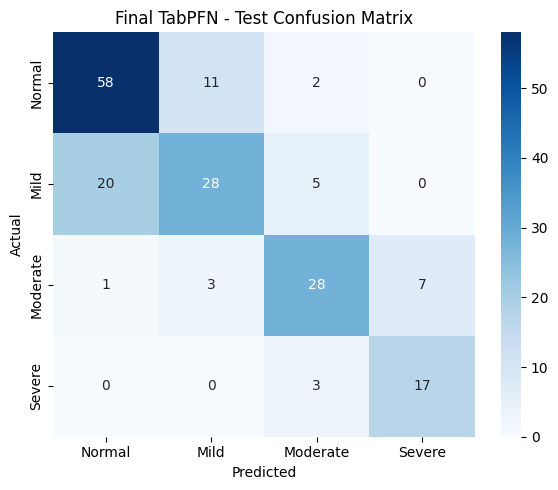

In [56]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix
test_cm = confusion_matrix(y_test_final, y_test_pred, labels=class_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Final TabPFN - Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Explainable AI

In [57]:
FEATURES = X_train_final.columns.tolist()

print(FEATURES)
print(X_train_final.shape)
print(X_test_final.shape)

['MUAP_Amplitude_uV', 'MUAP_Ration_ms', 'MUAP_Polyphasia_Percent']
(729, 3)
(183, 3)


In [58]:
X_explain = X_test_final.sample(50, random_state=42)

shap_values = interpretability.shap.get_shap_values(
    estimator=final_tabpfn_model,
    test_x=X_explain,
    attribute_names=FEATURES,
    algorithm="permutation"
)

PermutationExplainer explainer: 51it [31:44, 38.10s/it]


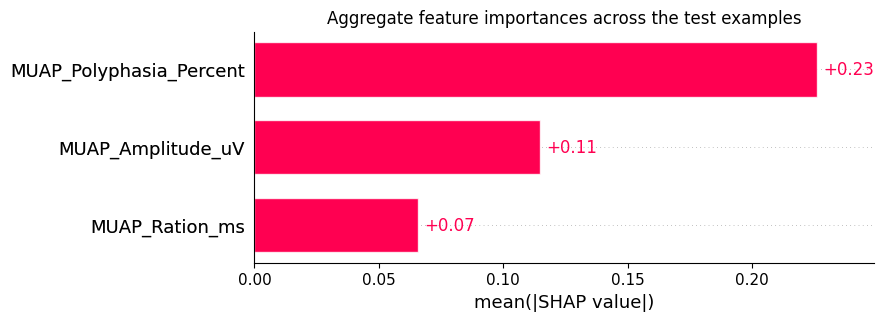

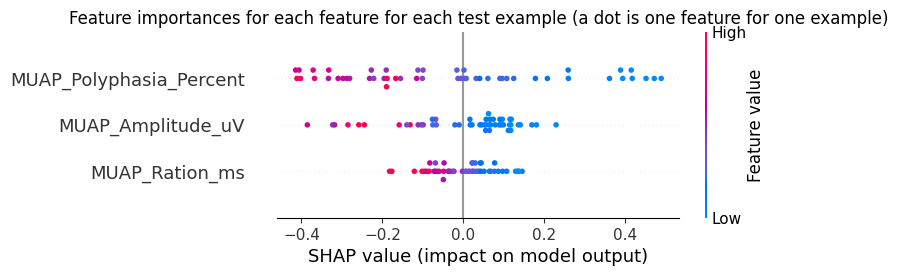

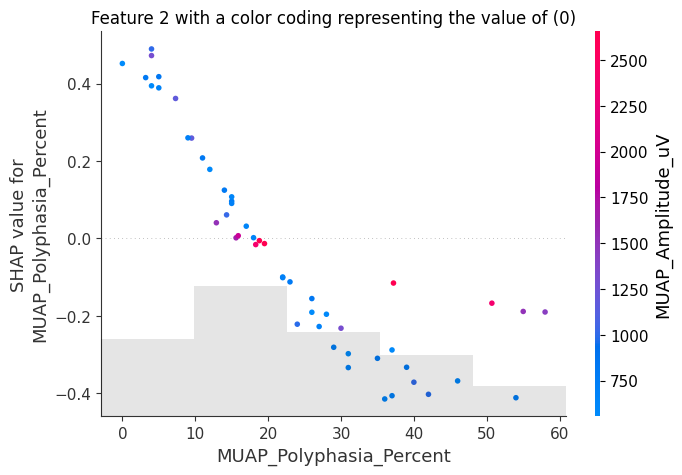

In [59]:
fig = interpretability.shap.plot_shap(shap_values)
plt.show()


SHAP for class: Normal


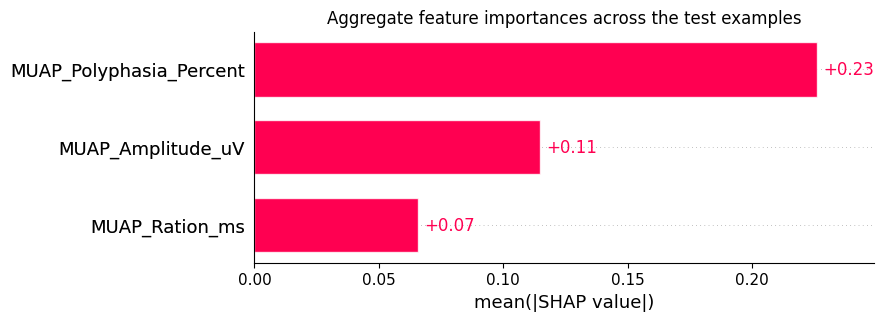

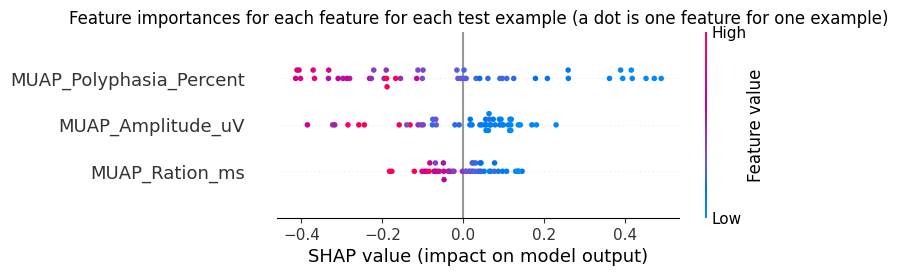

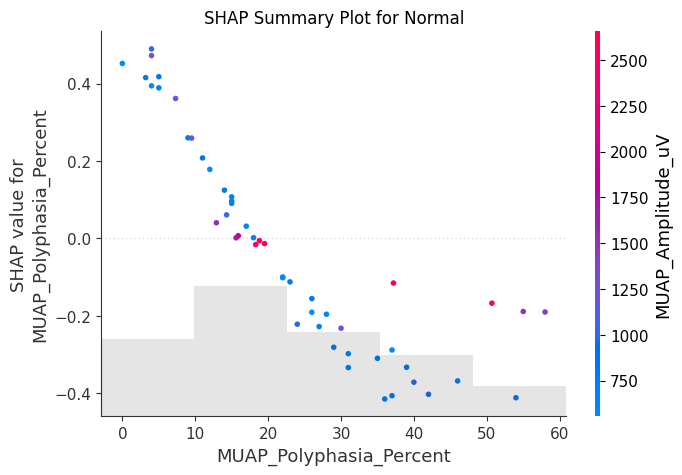


SHAP for class: Mild


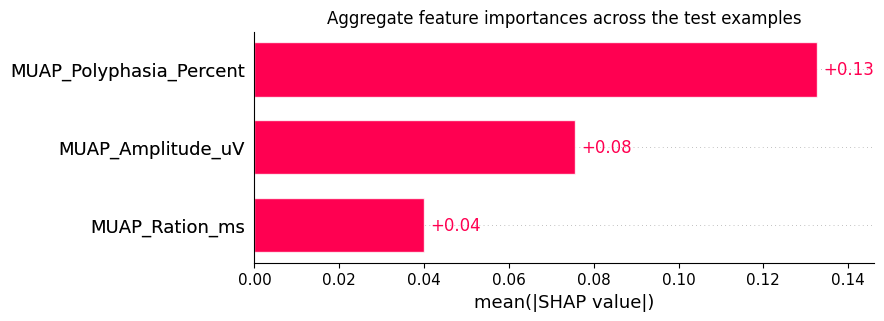

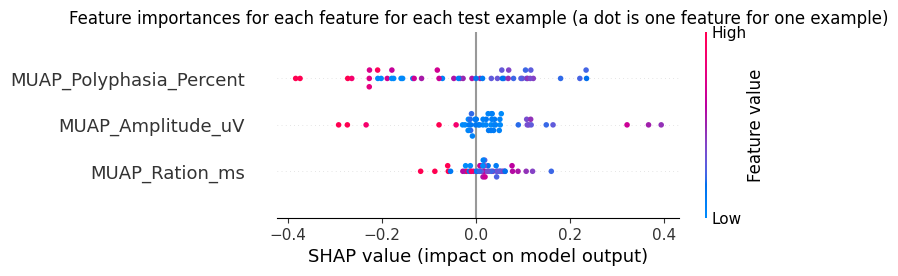

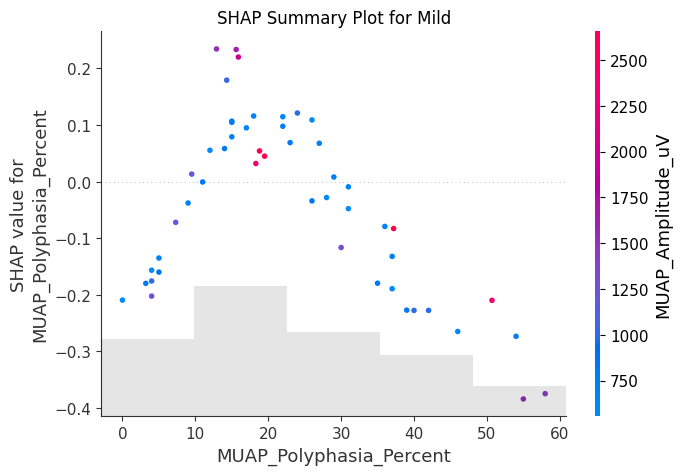


SHAP for class: Moderate


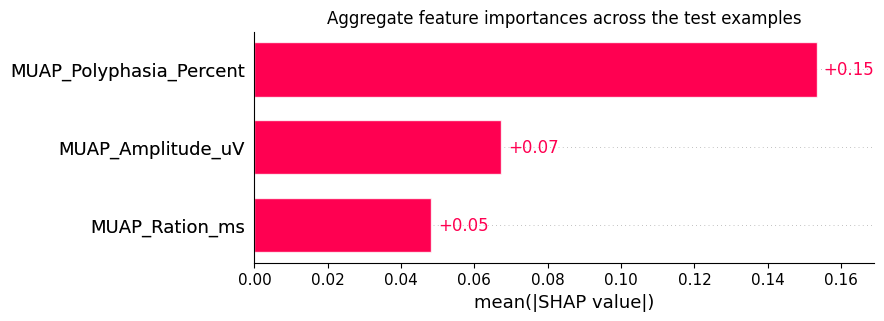

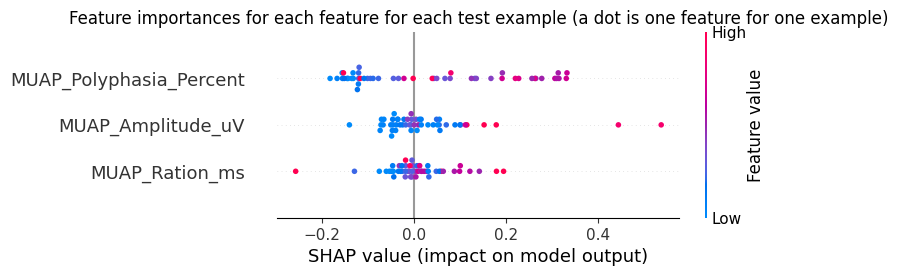

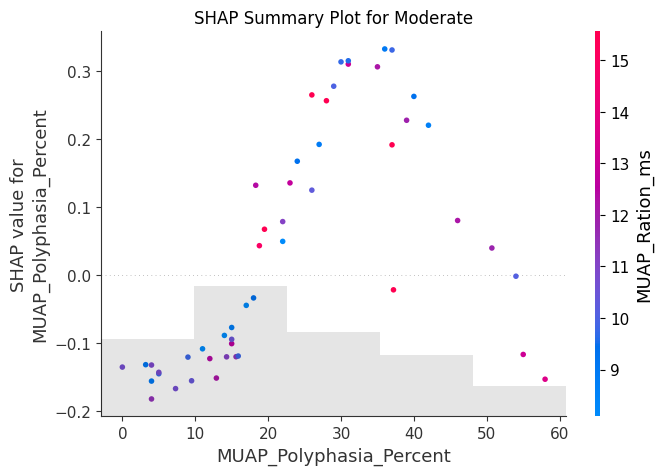


SHAP for class: Severe


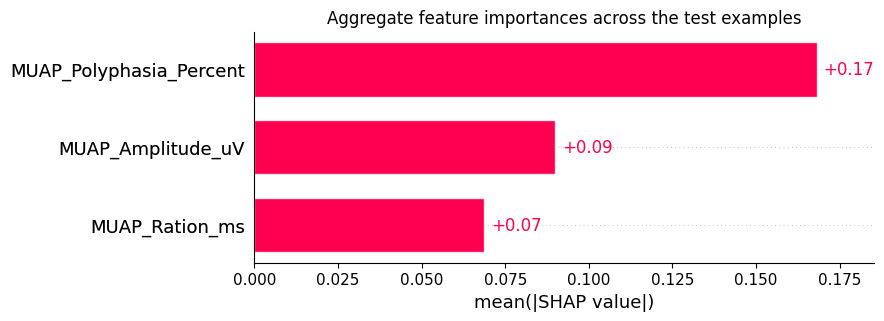

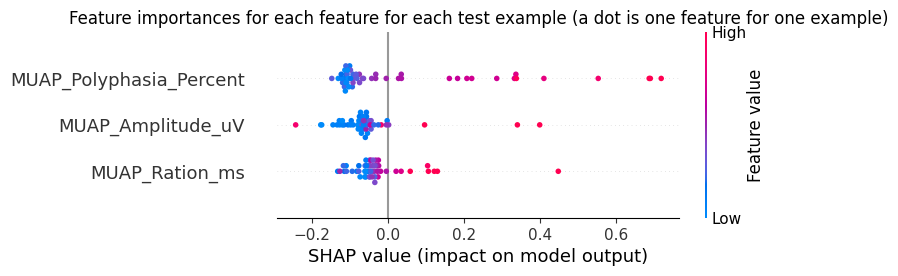

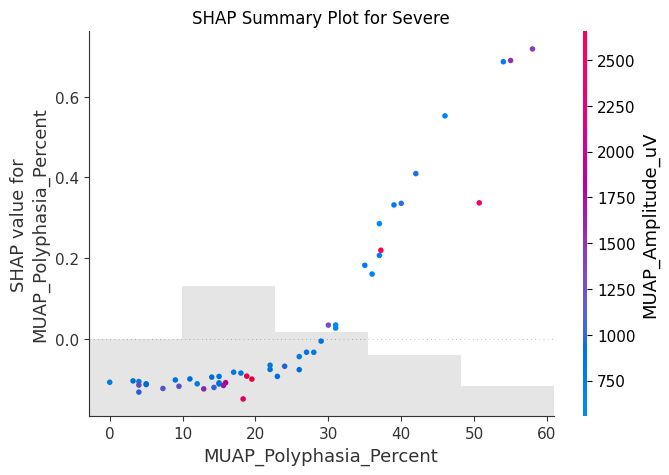

In [60]:
class_names = ["Normal", "Mild", "Moderate", "Severe"]

for i, class_name in enumerate(class_names):
    print(f"\nSHAP for class: {class_name}")

    shap_class = shap_values[..., i]

    fig = interpretability.shap.plot_shap(shap_class)
    plt.title(f"SHAP Summary Plot for {class_name}")
    plt.show()

In [63]:
values = shap_values.values

importance_all = []

for i, class_name in enumerate(class_names):
    importance = np.mean(np.abs(values[..., i]), axis=0)
    importance_all.append(importance)

tabpfn_importance_df = pd.DataFrame(
    np.array(importance_all).T,
    index=FEATURES,
    columns=class_names
)

tabpfn_importance_df

,Normal,Mild,Moderate,Severe
MUAP_Amplitude_uV,0.114700,0.075564,0.067311,0.090025
MUAP_Ration_ms,0.065633,0.039879,0.048198,0.068798
MUAP_Polyphasia_Percent,0.226064,0.132606,0.153400,0.168214


## Overfitting check

In [64]:
# Extract TabPFN CV aggregated metrics
best_cv_accuracy = tabpfn_selected_agg_metrics.loc[0, 'Accuracy']
best_cv_precision_macro = tabpfn_selected_agg_metrics.loc[0, 'Precision_macro']
best_cv_recall_macro = tabpfn_selected_agg_metrics.loc[0, 'Recall_macro']
best_cv_f1_macro = tabpfn_selected_agg_metrics.loc[0, 'F1_macro']
best_cv_mcc = tabpfn_selected_agg_metrics.loc[0, 'MCC']
best_cv_ap_severe = tabpfn_selected_agg_metrics.loc[0, 'AP_Severe']

# CV vs Test comparison
cv_vs_test_tabpfn_df = pd.DataFrame([
    ['CV', best_cv_accuracy, best_cv_precision_macro, best_cv_recall_macro, best_cv_f1_macro, best_cv_mcc, best_cv_ap_severe],
    ['Test Set', test_accuracy, test_precision_macro, test_recall_macro, test_f1_macro, test_mcc, test_ap_severe]
], columns=['Dataset', 'Accuracy', 'Precision_macro', 'Recall_macro', 'F1_macro', 'MCC', 'AP_Severe'])

cv_vs_test_tabpfn_df.iloc[:, 1:] = cv_vs_test_tabpfn_df.iloc[:, 1:].round(4)

print("CV vs Test Set")
display(cv_vs_test_tabpfn_df)

CV vs Test Set


,Dataset,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,CV,0.6790,0.6777,0.6743,0.6711,0.5474,0.8670
1,Test Set,0.7158,0.7115,0.7283,0.7157,0.6009,0.9058


In [65]:
# Compute generalization gap (CV - Test)

tabpfn_gap_df = pd.DataFrame([{
    'Accuracy_Gap': round(tabpfn_selected_agg_metrics.loc[0, 'Accuracy'] - test_accuracy, 4),
    'Precision_macro_Gap': round(tabpfn_selected_agg_metrics.loc[0, 'Precision_macro'] - test_precision_macro, 4),
    'Recall_macro_Gap': round(tabpfn_selected_agg_metrics.loc[0, 'Recall_macro'] - test_recall_macro, 4),
    'F1_macro_Gap': round(tabpfn_selected_agg_metrics.loc[0, 'F1_macro'] - test_f1_macro, 4),
    'MCC_Gap': round(tabpfn_selected_agg_metrics.loc[0, 'MCC'] - test_mcc, 4),
    'AP_Severe_Gap': round(tabpfn_selected_agg_metrics.loc[0, 'AP_Severe'] - test_ap_severe, 4)
}])

print("Overfitting Check (CV - Test)")
display(tabpfn_gap_df)

Overfitting Check (CV - Test)


,Accuracy_Gap,Precision_macro_Gap,Recall_macro_Gap,F1_macro_Gap,MCC_Gap,AP_Severe_Gap
0,-0.0368,-0.0338,-0.054,-0.0446,-0.0535,-0.0388


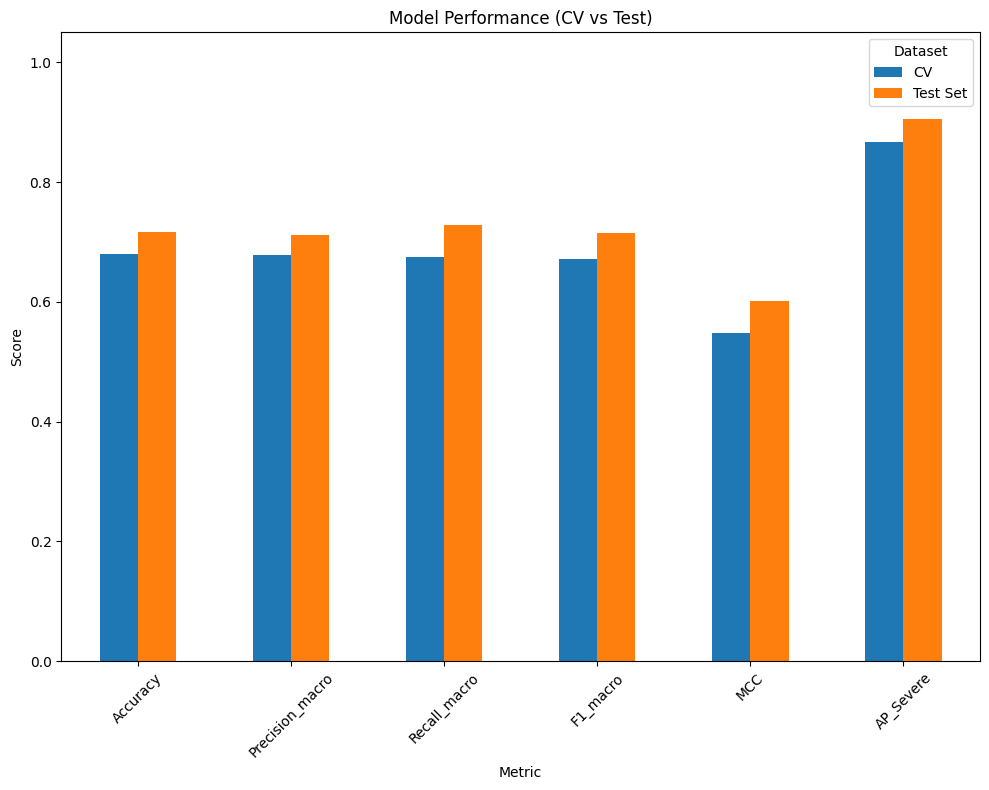

In [66]:
# Prepare data for plotting
plot_df = cv_vs_test_tabpfn_df.set_index('Dataset').T

# Plot comparison
plot_df.plot(kind='bar', figsize=(10, 8))

plt.title("Model Performance (CV vs Test)")
plt.ylabel("Score")
plt.xlabel("Metric")

plt.xticks(rotation=45)
plt.ylim(0, 1.05)

plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

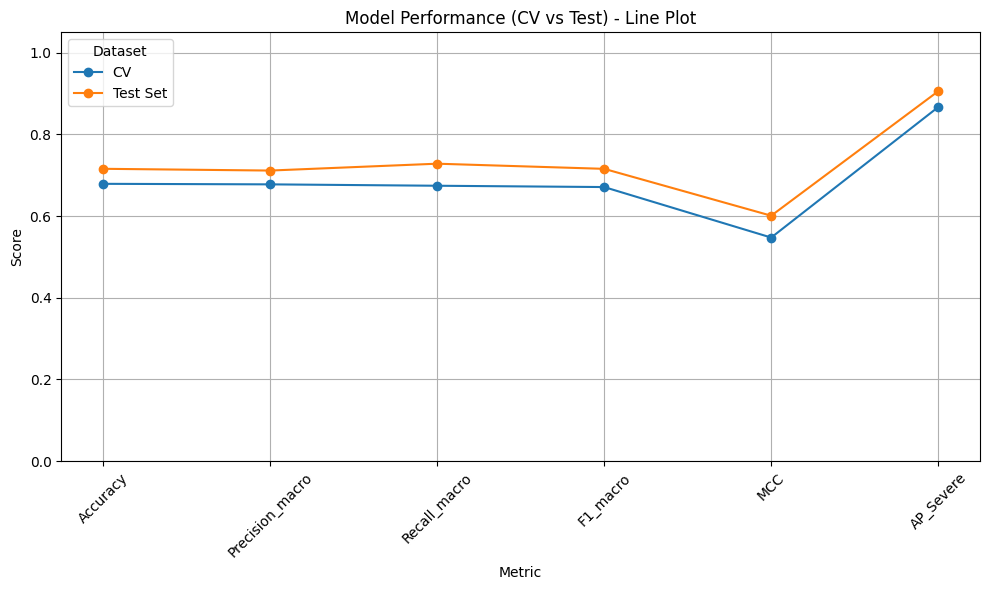

In [67]:
# Prepare data
plot_df = cv_vs_test_tabpfn_df.set_index('Dataset').T

# Line plot
plot_df.plot(marker='o', figsize=(10, 6))

plt.title("Model Performance (CV vs Test) - Line Plot")
plt.ylabel("Score")
plt.xlabel("Metric")

plt.xticks(rotation=45)
plt.ylim(0, 1.05)

plt.legend(title="Dataset")
plt.grid(True)

plt.tight_layout()
plt.show()

## Test Set Sample predictions

In [68]:
# Map numeric labels to class names
label_names = {
    0: 'Normal',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe'
}

# Build comparison table
sample_predictions_named = pd.DataFrame({
    'Actual': y_test_final.map(label_names).values,
    'Predicted': pd.Series(y_test_pred, index=y_test_final.index).map(label_names).values
}, index=y_test_final.index)

print("Sample Predictions with Class Names")
display(sample_predictions_named.head(10))

Sample Predictions with Class Names


,Actual,Predicted
515,Moderate,Severe
872,Normal,Normal
224,Normal,Normal
648,Severe,Severe
862,Mild,Mild
486,Normal,Normal
208,Mild,Normal
830,Normal,Mild
630,Normal,Normal
530,Severe,Moderate


In [69]:
# Predict class labels
y_test_pred = final_tabpfn_model.predict(X_test_final)

# Predict probabilities
y_test_proba = final_tabpfn_model.predict_proba(X_test_final)

# Map numeric labels to class names
label_mapping = {
    0: 'Normal',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe'
}

# Convert actual and predicted labels to names
sample_predictions_named = pd.DataFrame({
    'Actual': pd.Series(y_test_final).map(label_mapping),
    'Predicted': pd.Series(y_test_pred, index=y_test_final.index).map(label_mapping)
}, index=y_test_final.index)

# Create probability dataframe
proba_df = pd.DataFrame(
    y_test_proba,
    columns=['Prob_Normal', 'Prob_Mild', 'Prob_Moderate', 'Prob_Severe'],
    index=y_test_final.index
)

# Combine everything
prediction_with_proba = pd.concat([sample_predictions_named, proba_df], axis=1)

print("Sample Predictions with Probabilities - TabPFN")
display(prediction_with_proba.head(10))

Sample Predictions with Probabilities - TabPFN


,Actual,Predicted,Prob_Normal,Prob_Mild,Prob_Moderate,Prob_Severe
515,Moderate,Severe,0.000728,0.010297,0.449579,0.539397
872,Normal,Normal,0.710905,0.282214,0.006862,0.000018
224,Normal,Normal,0.677215,0.322007,0.000772,0.000006
648,Severe,Severe,0.000016,0.000359,0.189475,0.810151
862,Mild,Mild,0.402379,0.429725,0.167617,0.000278
486,Normal,Normal,0.564824,0.391520,0.043631,0.000025
208,Mild,Normal,0.917521,0.082279,0.000195,0.000005
830,Normal,Mild,0.074114,0.575817,0.347737,0.002333
630,Normal,Normal,0.465647,0.407044,0.127094,0.000215
530,Severe,Moderate,0.085802,0.264120,0.603424,0.046654


In [70]:
# Show only incorrect predictions
errors_df = prediction_with_proba[
    prediction_with_proba['Actual'] != prediction_with_proba['Predicted']
]

print("Misclassified Samples")
display(errors_df.head(10))

Misclassified Samples


,Actual,Predicted,Prob_Normal,Prob_Mild,Prob_Moderate,Prob_Severe
515,Moderate,Severe,0.000728,0.010297,0.449579,0.539397
208,Mild,Normal,0.917521,0.082279,0.000195,0.000005
830,Normal,Mild,0.074114,0.575817,0.347737,0.002333
530,Severe,Moderate,0.085802,0.264120,0.603424,0.046654
322,Moderate,Severe,0.000369,0.007164,0.363538,0.628929
324,Mild,Normal,0.869427,0.130414,0.000158,0.000002
760,Moderate,Mild,0.393571,0.439960,0.165900,0.000569
372,Mild,Moderate,0.001575,0.301780,0.632859,0.063786
624,Mild,Normal,0.471183,0.408928,0.119749,0.000140
415,Normal,Mild,0.372114,0.442191,0.184836,0.000858


# Save the full model

## Train on Full Dataset( Train + Test)

In [71]:
# Combine train + test for final deployment model
X_full_selected = pd.concat([
    X_train[selected_features],
    X_test[selected_features]
], axis=0)

y_full = pd.concat([y_train, y_test], axis=0)

# Reset index
X_full_selected = X_full_selected.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# Clean feature names for consistency
X_full_selected.columns = X_full_selected.columns.str.replace(' ', '_')

print("Full dataset shape :", X_full_selected.shape)
print("Full target shape  :", y_full.shape)
print("Selected features  :", list(X_full_selected.columns))

Full dataset shape : (912, 3)
Full target shape  : (912,)
Selected features  : ['MUAP_Amplitude_uV', 'MUAP_Ration_ms', 'MUAP_Polyphasia_Percent']


In [72]:
# Define target mapping
target_mapping = {
    'Normal': 0,
    'Mild': 1,
    'Moderate': 2,
    'Severe': 3
}

# Convert y if still text
if y_full.dtype == 'object':
    y_full_final = y_full.map(target_mapping)
else:
    y_full_final = y_full.copy()

print("Unique full labels:", sorted(y_full_final.unique()))

Unique full labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [73]:
from tabpfn import TabPFNClassifier

# Build final deployment TabPFN model
final_deployment_tabpfn_model = TabPFNClassifier()

# Train on full dataset
final_deployment_tabpfn_model.fit(X_full_selected, y_full_final)

print("Final deployment TabPFN model has been trained on the full dataset.")

Final deployment TabPFN model has been trained on the full dataset.


In [74]:
import joblib

deployment_bundle = {
    'model': final_deployment_tabpfn_model,
    'selected_features': list(X_full_selected.columns),
    'label_names': {
        0: 'Normal',
        1: 'Mild',
        2: 'Moderate',
        3: 'Severe'
    }
}

joblib.dump(deployment_bundle, 'final_tabpfn_deployment_bundle.pkl')

print("Deployment bundle saved successfully.")

Deployment bundle saved successfully.


In [75]:
# Load the saved bundle
deployment_bundle = joblib.load('final_tabpfn_deployment_bundle.pkl')

loaded_model = deployment_bundle['model']
loaded_selected_features = deployment_bundle['selected_features']
loaded_label_names = deployment_bundle['label_names']

print("Bundle loaded successfully.")
print("Loaded selected features:", loaded_selected_features)
print("Loaded label names:", loaded_label_names)

Bundle loaded successfully.
Loaded selected features: ['MUAP_Amplitude_uV', 'MUAP_Ration_ms', 'MUAP_Polyphasia_Percent']
Loaded label names: {0: 'Normal', 1: 'Mild', 2: 'Moderate', 3: 'Severe'}


# New sample prediction

In [76]:
# New unseen sample
new_sample = pd.DataFrame([{
    'MUAP Polyphasia Percent': 35,
    'MUAP Ration ms': 12,
    'MUAP Amplitude uV': 450
}])

# Clean column names to match training
new_sample.columns = new_sample.columns.str.replace(' ', '_')

# Use loaded selected features and keep same order
new_sample = new_sample[loaded_selected_features].copy()

# Predict
new_prediction = loaded_model.predict(new_sample)[0]
new_prediction_proba = loaded_model.predict_proba(new_sample)[0]

print("EMG Input Values:")
for col, val in new_sample.iloc[0].items():
    print(f"{col}: {val}")

print("\nPredicted Strength Severity:")
print(f"{loaded_label_names[new_prediction]}")

print("\nConfidence Scores Across Classes:")
for i, prob in enumerate(new_prediction_proba):
    class_name = loaded_label_names[i]
    print(f"{class_name:9}: {prob*100:.1f}%")

EMG Input Values:
MUAP_Amplitude_uV: 450
MUAP_Ration_ms: 12
MUAP_Polyphasia_Percent: 35

Predicted Strength Severity:
Moderate

Confidence Scores Across Classes:
Normal   : 3.6%
Mild     : 15.6%
Moderate : 65.7%
Severe   : 15.2%
